# Customer Segmentation Analysis — RFM + K-Means Clustering

**Objective:** Segment an e-commerce company's customers into distinct behavioural groups
using RFM (Recency, Frequency, Monetary) features and K-Means clustering, then translate
each segment into a concrete marketing action.

**Dataset:** The [UCI "Online Retail" dataset](https://archive.ics.uci.edu/dataset/352/online+retail)
— real transaction-level data from a UK-based, non-store online retailer selling
all-occasion gifts, covering **541,909 order lines** between **1 Dec 2010 and 9 Dec 2011**.
Unlike a lot of teaching datasets, this one is genuinely messy — it has real missing
customer IDs, real cancellations, and real data-entry inconsistencies — so the cleaning
section below isn't cosmetic, it's a real part of the analysis. No synthetic data is used
anywhere in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 50)

df = pd.read_csv("online_retail_dataset.csv.gz", parse_dates=['InvoiceDate'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 1. Initial Inspection

In [2]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
df.info()

Shape: 541,909 rows x 8 columns

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


In [3]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
pd.DataFrame({
    'missing_count': nulls,
    'missing_pct': (nulls / len(df) * 100).round(2)
})

,missing_count,missing_pct
Description,1454,0.27
CustomerID,135080,24.93


**Observation:** `CustomerID` is missing on **135,080 rows (~24.9%)** — a full quarter of
the transactions. `Description` is missing on a much smaller 1,454 rows (~0.27%). There
are also structural inconsistencies that a plain `.isnull()` check won't catch: negative
`Quantity` values (returns), a small number of negative or zero `UnitPrice` values
(adjustments / free items), and `InvoiceNo` values that start with the letter **"C"**,
which the dataset's documentation defines as cancelled orders. All of these need to be
handled before we can build a trustworthy customer-level profile.

In [4]:
print(f"Negative Quantity (returns):        {(df['Quantity'] < 0).sum():,}")
print(f"Non-positive UnitPrice (adjustments): {(df['UnitPrice'] <= 0).sum():,}")
print(f"Cancelled invoices (start with 'C'): {df['InvoiceNo'].astype(str).str.startswith('C').sum():,}")

Negative Quantity (returns):        10,624
Non-positive UnitPrice (adjustments): 2,517


Cancelled invoices (start with 'C'): 9,288


## 2. Handling Missing Values and Inconsistent Data

Decisions, and why:
- **Missing `CustomerID` → drop.** This is a customer segmentation task; a transaction we
  can't attribute to a customer can't be used, and imputing a fake customer ID would create
  a phantom mega-customer. 24.9% is a lot to lose, but it's unusable for this specific goal.
- **Cancelled invoices (`InvoiceNo` starting with "C") → drop.** These represent orders that
  were reversed, not genuine completed purchases.
- **Non-positive `Quantity` or `UnitPrice` → drop.** Leftover returns/adjustments not
  already caught above, and free/zero-value line items that would understate spend.
- **Missing `Description` → keep, no action needed.** We don't use product descriptions for
  clustering, so this has no bearing on the analysis.

In [5]:
before = len(df)
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning:  {len(df_clean):,}  ({len(df_clean)/before:.1%} retained)")
print(f"Unique customers remaining: {df_clean['CustomerID'].nunique():,}")

Rows before cleaning: 541,909
Rows after cleaning:  397,884  (73.4% retained)
Unique customers remaining: 4,338


## 3. Descriptive Statistics

Average purchase value, purchase frequency, and a simplified historical customer lifetime
value (total revenue generated per customer over the observed 12-month window).

In [6]:
order_value = df_clean.groupby('InvoiceNo')['TotalPrice'].sum()

per_customer = df_clean.groupby('CustomerID').agg(
    Frequency=('InvoiceNo', 'nunique'),
    Historical_CLV=('TotalPrice', 'sum')
)

desc_stats = pd.DataFrame({
    'Average Order Value ($)': order_value.describe()[['mean', '50%', 'std']].rename({'50%': 'median'}),
    'Purchase Frequency (orders/customer)': per_customer['Frequency'].describe()[['mean', '50%', 'std']].rename({'50%': 'median'}),
    'Historical CLV ($/customer)': per_customer['Historical_CLV'].describe()[['mean', '50%', 'std']].rename({'50%': 'median'}),
}).round(2)
desc_stats

,Average Order Value ($),Purchase Frequency (orders/customer),Historical CLV ($/customer)
mean,480.87,4.27,2054.27
median,303.04,2.00,674.48
std,1678.20,7.70,8989.23


**Observation:** The average order is worth roughly **\$481**, but the median order is only
**\$303** — and that gap between mean and median shows up in every one of these metrics,
a clear sign of right-skew. A
relatively small number of high-value, high-frequency customers (likely wholesalers, per
the dataset's own documentation) are pulling the averages well above what a "typical"
customer looks like. This directly motivates why we log-transform Frequency and Monetary
before clustering in Section 5 — without it, K-Means would be dominated by a handful of
extreme outliers rather than finding genuine behavioural groups.

## 4. Feature Selection: RFM (Recency, Frequency, Monetary)

We use the three classic behavioural features for customer segmentation:
- **Recency** — days since the customer's most recent purchase (relative to one day after
  the dataset's last recorded transaction)
- **Frequency** — number of distinct orders (invoices) placed
- **Monetary** — total amount spent

These three numbers compactly describe *when* a customer last engaged, *how often* they
engage, and *how much* they're worth — exactly the dimensions a marketing team acts on.

In [7]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(f"Snapshot date used for Recency: {snapshot_date.date()}")
rfm.describe().round(1)

Snapshot date used for Recency: 2011-12-10


,CustomerID,Recency,Frequency,Monetary
count,4338.0,4338.0,4338.0,4338.0
mean,15300.4,92.5,4.3,2054.3
std,1721.8,100.0,7.7,8989.2
min,12346.0,1.0,1.0,3.8
25%,13813.2,18.0,1.0,307.4
50%,15299.5,51.0,2.0,674.5
75%,16778.8,142.0,5.0,1661.7
max,18287.0,374.0,209.0,280206.0


## 5. Standardisation Before Clustering

Frequency and Monetary are heavily right-skewed (Section 3), so we log-transform them
first, then apply `StandardScaler` to put all three features on the same scale — essential
for K-Means, which is distance-based and would otherwise let Monetary (measured in
hundreds/thousands of dollars) dominate Recency and Frequency (measured in single/double
digits).

In [8]:
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

features = ['Recency', 'Frequency_log', 'Monetary_log']
X_scaled = StandardScaler().fit_transform(rfm[features])
print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (4338, 3)


## 6. K-Means Clustering — Choosing K with the Elbow Method

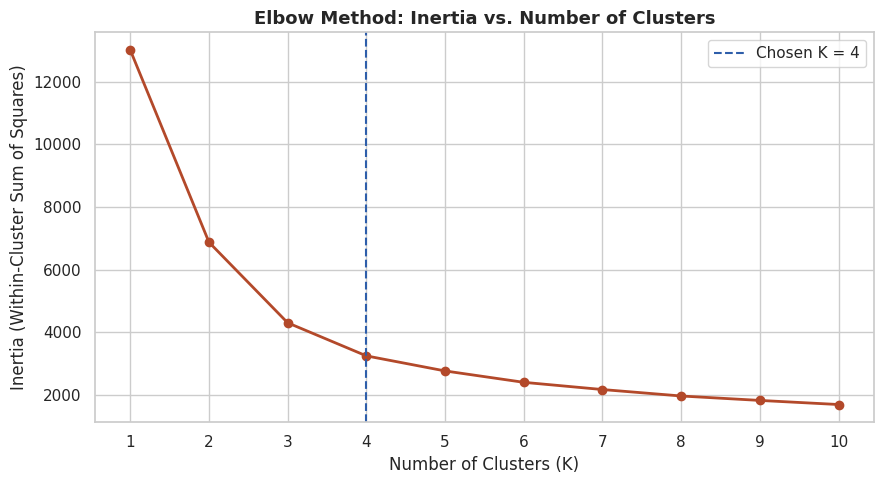

In [9]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_range, inertias, marker='o', color='#B3492A', linewidth=2)
ax.axvline(4, color='#2E5EAA', linestyle='--', linewidth=1.5, label='Chosen K = 4')
ax.set_title('Elbow Method: Inertia vs. Number of Clusters')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** Inertia drops sharply from K=1 through K=4, then the rate of improvement
clearly flattens out from K=5 onward — each additional cluster after 4 buys progressively
less separation. **K=4** is the elbow: enough clusters to capture meaningfully different
customer types without over-fragmenting the base into segments too small to act on.

In [10]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)
print("Customers per cluster:\n", rfm['Cluster'].value_counts().sort_index())

Customers per cluster:
 Cluster
0    1447
1    1392
2     941
3     558
Name: count, dtype: int64


## 7. Visualising the Clusters

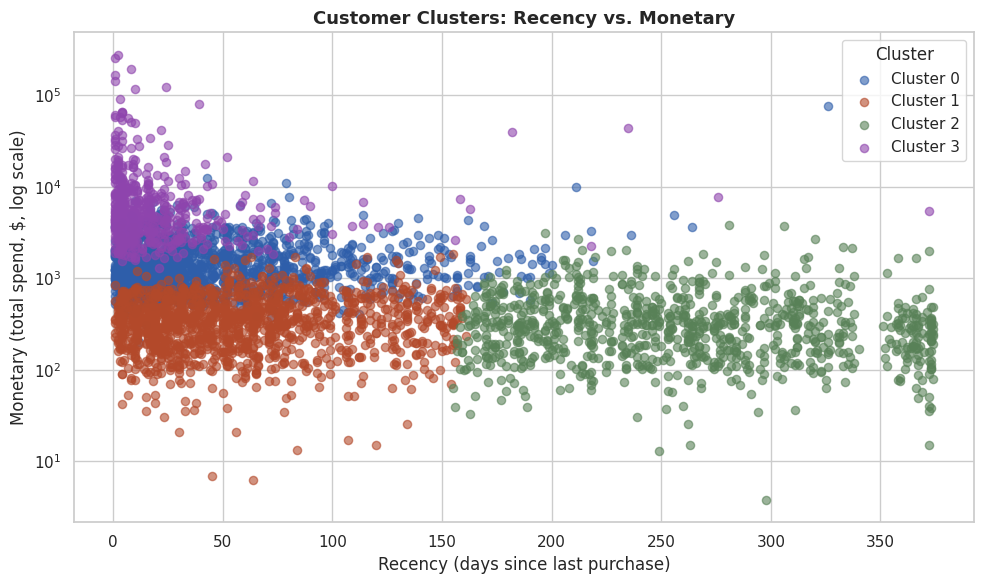

In [11]:
palette = {0: '#2E5EAA', 1: '#B3492A', 2: '#588157', 3: '#8E44AD'}

fig, ax = plt.subplots(figsize=(10, 6))
for c in sorted(rfm['Cluster'].unique()):
    sub = rfm[rfm['Cluster'] == c]
    ax.scatter(sub['Recency'], sub['Monetary'], label=f'Cluster {c}',
               color=palette[c], alpha=0.6, s=35)
ax.set_yscale('log')
ax.set_title('Customer Clusters: Recency vs. Monetary')
ax.set_xlabel('Recency (days since last purchase)')
ax.set_ylabel('Monetary (total spend, $, log scale)')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

**Observation:** There's a clear pocket of customers in the bottom-right — high recency
(haven't bought in a long time) and low monetary value — clearly separated from a
top-left cluster of low-recency, high-monetary customers who are both engaged *and*
valuable.

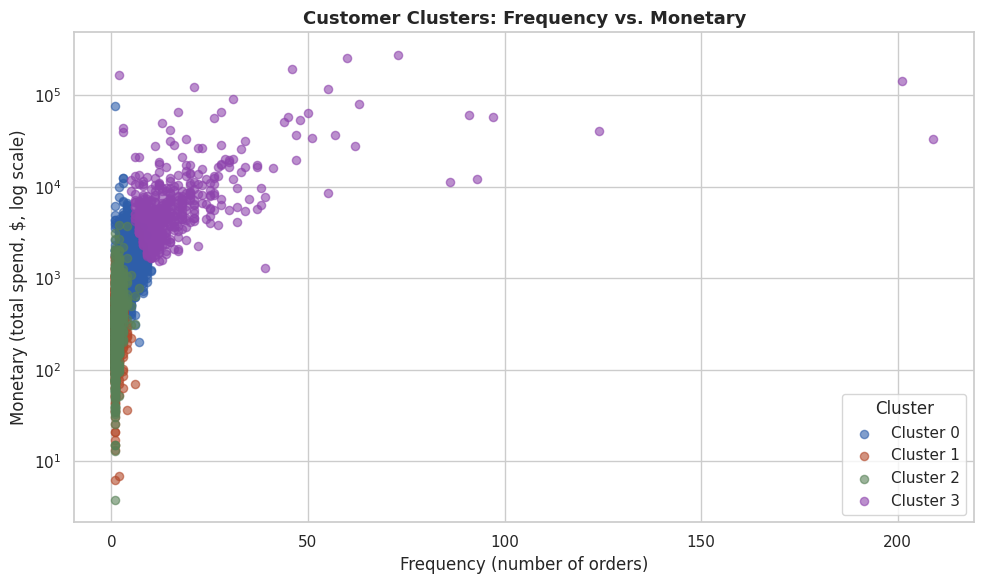

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
for c in sorted(rfm['Cluster'].unique()):
    sub = rfm[rfm['Cluster'] == c]
    ax.scatter(sub['Frequency'], sub['Monetary'], label=f'Cluster {c}',
               color=palette[c], alpha=0.6, s=35)
ax.set_yscale('log')
ax.set_title('Customer Clusters: Frequency vs. Monetary')
ax.set_xlabel('Frequency (number of orders)')
ax.set_ylabel('Monetary (total spend, $, log scale)')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

**Observation:** Frequency and Monetary move together, as expected (more orders generally
means more total spend) — but the clustering isn't just splitting on this one dimension.
The same customers that stand out for high frequency also tend to be the low-recency
group from the chart above, which is exactly the profile of a business's best customers.

## 8. Cluster Profiles

In [13]:
profile = rfm.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency_days=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
).round(1)
profile['% of customer base'] = (profile['Customers'] / profile['Customers'].sum() * 100).round(1)
profile

,Customers,Avg_Recency_days,Avg_Frequency,Avg_Monetary,% of customer base
Cluster,,,,,
0,1447,45.4,4.3,1667.7,33.4
1,1392,58.1,1.5,392.9,32.1
2,941,259.2,1.4,390.2,21.7
3,558,19.5,16.0,10007.5,12.9


**Cluster descriptions (based on the profile above):**

| Cluster | Recency | Frequency | Monetary | Customer type |
|---|---|---|---|---|
| 3 | Lowest (~20 days) | Highest (~16 orders) | Highest (~\$10,000) | **Champions** — recently active, frequent, high-spend. The core of the business. |
| 0 | Moderate (~45 days) | Moderate (~4 orders) | Moderate (~\$1,700) | **Loyal / Regular** — steady repeat buyers who haven't reached VIP status. |
| 1 | Moderate (~58 days) | Low (~1-2 orders) | Low (~\$390) | **New / Occasional** — recently acquired but haven't built a buying habit yet. |
| 2 | Highest (~260 days) | Low (~1-2 orders) | Low (~\$390) | **At Risk / Lapsed** — haven't purchased in the better part of a year. |

## 9. Customers per Cluster

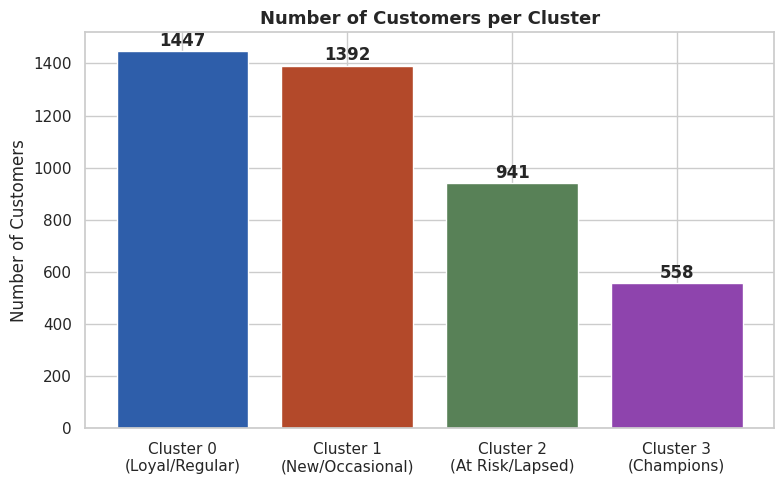

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
counts = rfm['Cluster'].value_counts().sort_index()
labels = ['Loyal/Regular', 'New/Occasional', 'At Risk/Lapsed', 'Champions']
ax.bar([f'Cluster {i}\n({labels[i]})' for i in counts.index], counts.values,
       color=[palette[i] for i in counts.index])
ax.set_title('Number of Customers per Cluster')
ax.set_ylabel('Number of Customers')
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** "Champions" are the smallest group (~13% of customers) but — going back
to Section 8 — contribute by far the most revenue per head, which is the classic 80/20
pattern retail businesses see. "Loyal/Regular" and "New/Occasional" together make up the
bulk of the customer base, and "At Risk/Lapsed" is large enough (~22%) that ignoring it
would mean writing off a real chunk of the customer list.

## 10. Insights & Recommended Marketing Actions

| Segment | Who they are | Recommended marketing action |
|---|---|---|
| **Champions** | Recent, frequent, highest spend | Launch a VIP/loyalty tier with early access and exclusive perks; ask for reviews/referrals — they're the most credible advocates; avoid discount-heavy campaigns that erode margin on customers who'd buy anyway. |
| **Loyal/Regular** | Steady but not top-tier | Cross-sell and upsell campaigns based on past purchase categories; a "spend \$X more, unlock Champions perks" nudge to push them up a tier. |
| **New/Occasional** | Recently acquired, low order count | A second-purchase incentive (time-limited discount on their next order) and onboarding content to build the buying habit before they go cold. |
| **At Risk/Lapsed** | Haven't purchased in ~9 months | A win-back email campaign with a meaningful incentive; if unresponsive after 1-2 attempts, move to low-cost/low-frequency contact rather than continuing to spend acquisition-level budget on them. |

**Bottom line:** with roughly 13% of customers (Champions) driving a disproportionate
share of revenue, and another ~22% (At Risk/Lapsed) at risk of being fully lost, the
highest-leverage moves are (1) protecting and rewarding the Champions segment so it
doesn't churn, and (2) running a targeted win-back campaign on the At Risk segment before
they age further past the ~9-month mark and become effectively unreachable.